In [1]:
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

RESULTS_DIR = Path('results')

# Ablation axes — mirrors ABLATION in run_experiments.py
PARTS = ['task', 'prepost', 'err', 'sig', 'syn', 'fsig']

PART_LABELS = {
    'task':    'Task instruction',
    'prepost': 'Pre/post identifiers',
    'err':     'Error message',
    'sig':     'Verbatim signature',
    'syn':     'Syntax guide',
    'fsig':    'Full sig (require/ensure)',
}

In [2]:
def parse_tag(tag):
    """Return dict {part: bool} — True if part is present in this ablation."""
    disabled = set(re.findall(r'no_([a-z]+)', tag))
    return {p: (p not in disabled) for p in PARTS}


def extract_interaction_metrics(interactions):
    total_cost = total_prompt_tokens = total_completion_tokens = total_tokens = 0
    total_verification_time = total_ai_time = 0.0
    n_suggestions = n_accepted = n_rejected = 0

    for ix in interactions:
        total_verification_time += ix.get('verification_time_seconds', 0.0)
        total_ai_time           += ix.get('ai_request_time_seconds', 0.0)
        for sg in ix.get('suggestions', []):
            total_cost              += sg.get('cost', 0.0)
            total_prompt_tokens     += sg.get('prompt_tokens', 0)
            total_completion_tokens += sg.get('completion_tokens', 0)
            total_tokens            += sg.get('total_tokens', 0)
            n_suggestions += 1
            if sg.get('accepted'): n_accepted += 1
            else:                  n_rejected += 1

    return dict(
        total_cost=total_cost,
        total_prompt_tokens=total_prompt_tokens,
        total_completion_tokens=total_completion_tokens,
        total_tokens=total_tokens,
        total_verification_time=total_verification_time,
        total_ai_time=total_ai_time,
        n_suggestions=n_suggestions,
        n_accepted=n_accepted,
        n_rejected=n_rejected,
    )


records = []
for dataset_dir in sorted(RESULTS_DIR.iterdir()):
    if not dataset_dir.is_dir() or dataset_dir.name == 'html':
        continue
    for model_dir in sorted(dataset_dir.iterdir()):
        if not model_dir.is_dir():
            continue
        for jf in sorted(model_dir.glob('*.jsonl')):
            tag = jf.stem
            parts = parse_tag(tag)
            with open(jf) as f:
                for line in f:
                    line = line.strip()
                    if not line or line.startswith('>>'):
                        continue
                    try:
                        rec = json.loads(line)
                    except json.JSONDecodeError:
                        continue
                    rec['dataset']      = dataset_dir.name
                    rec['model_slug']   = model_dir.name
                    rec['ablation_tag'] = tag
                    rec['n_parts_on']   = sum(parts.values())
                    rec['n_parts_off']  = len(PARTS) - sum(parts.values())
                    for p in PARTS:
                        rec[f'has_{p}'] = parts[p]
                    rec.update(extract_interaction_metrics(rec.get('interactions', [])))
                    rec.setdefault('total_elapsed_time_seconds', 0.0)
                    rec.setdefault('max_retries_reached', False)
                    rec.setdefault('rate_limited', False)
                    records.append(rec)

df_all = pd.DataFrame(records)
df_all['class_feature'] = df_all['class_name'] + '.' + df_all['feature_name']

# Exclude rate-limited runs — they are incomplete and skew all metrics
df = df_all[~df_all['rate_limited']].copy()

models = sorted(df['model_slug'].unique())
datasets = sorted(df['dataset'].unique())

print(f'Total records     : {len(df_all)}')
print(f'  – rate-limited  : {df_all["rate_limited"].sum()}  (excluded from analysis)')
print(f'  – analysed      : {len(df)}')
print(f'Datasets          : {datasets}')
print(f'Models            : {models}')
print(f'Ablation tags     : {df["ablation_tag"].nunique()} unique')
print(f'Features          : {df["class_feature"].nunique()} unique')
print(f'Success rate      : {df["success"].mean()*100:.1f}%')
print(f'Total cost        : ${df["total_cost"].sum():.6f}')
print(f'Total tokens      : {df["total_tokens"].sum():,}')

Total records     : 545
  – rate-limited  : 21  (excluded from analysis)
  – analysed      : 524
Datasets          : ['buggy-java-jml-eiffel', 'maple-recursive']
Models            : ['inclusionai_ling-2.6-flash', 'mistralai_codestral-2508', 'mistralai_ministral-3b-2512']
Ablation tags     : 64 unique
Features          : 29 unique
Success rate      : 61.6%
Total cost        : $0.363698
Total tokens      : 2,545,804


## Ablation report

For each prompt part we measure the **marginal effect** of including it vs. omitting it,
aggregated across all models, datasets, and feature instances.  
We report success rate, mean elapsed time, mean prompt tokens, mean completion tokens,
and mean cost per run.

In [3]:
# ── per-ablation summary table ────────────────────────────────────────────────
agg = (
    df.groupby('ablation_tag')
    .agg(
        n                   = ('success', 'count'),
        success_rate        = ('success', 'mean'),
        mean_elapsed        = ('total_elapsed_time_seconds', 'mean'),
        mean_verif_time     = ('total_verification_time', 'mean'),
        mean_ai_time        = ('total_ai_time', 'mean'),
        mean_prompt_tokens  = ('total_prompt_tokens', 'mean'),
        mean_compl_tokens   = ('total_completion_tokens', 'mean'),
        mean_total_tokens   = ('total_tokens', 'mean'),
        mean_cost           = ('total_cost', 'mean'),
        n_parts_off         = ('n_parts_off', 'first'),
    )
    .reset_index()
    .sort_values(['n_parts_off', 'success_rate'], ascending=[True, False])
)

# Add part-flag columns for display
part_flags = (
    df.groupby('ablation_tag')[[f'has_{p}' for p in PARTS]].first().reset_index()
)
agg = agg.merge(part_flags, on='ablation_tag')

# Readable display
display_cols = (['ablation_tag'] +
                [f'has_{p}' for p in PARTS] +
                ['n', 'success_rate', 'mean_elapsed',
                 'mean_prompt_tokens', 'mean_compl_tokens', 'mean_cost'])
disp = agg[display_cols].copy()
disp['success_rate']       = (disp['success_rate'] * 100).round(1)
disp['mean_elapsed']       = disp['mean_elapsed'].round(1)
disp['mean_prompt_tokens'] = disp['mean_prompt_tokens'].round(0).astype(int)
disp['mean_compl_tokens']  = disp['mean_compl_tokens'].round(0).astype(int)
disp['mean_cost']          = disp['mean_cost'].map('${:.6f}'.format)
for p in PARTS:
    disp[f'has_{p}'] = disp[f'has_{p}'].map({True: '✓', False: '✗'})
disp.columns = (['Ablation'] + PARTS +
                ['N', 'Succ%', 'Elapsed(s)',
                 'Tok-in', 'Tok-out', 'Cost'])
print(f'All {len(disp)} ablation configurations:')
with pd.option_context('display.max_rows', 200, 'display.width', 200):
    display(disp)

All 64 ablation configurations:


,Ablation,task,prepost,err,sig,syn,fsig,N,Succ%,Elapsed(s),Tok-in,Tok-out,Cost
0,full,✓,✓,✓,✓,✓,✓,34,70.6,22.8,5117,505,$0.001194
1,no_prepost,✓,✗,✓,✓,✓,✓,9,77.8,18.8,5319,607,$0.000504
2,no_sig,✓,✓,✓,✗,✓,✓,9,77.8,40.6,4844,1542,$0.000616
3,no_syn,✓,✓,✓,✓,✗,✓,8,75.0,19.6,3694,485,$0.000627
4,no_err,✓,✓,✗,✓,✓,✓,9,66.7,25.4,4067,626,$0.000398
5,no_task,✗,✓,✓,✓,✓,✓,9,66.7,23.6,5556,644,$0.000758
6,no_fsig,✓,✓,✓,✓,✓,✗,8,50.0,39.0,6987,1625,$0.001192
7,no_err_no_syn,✓,✓,✗,✓,✗,✓,8,75.0,24.7,2340,629,$0.000364
8,no_sig_no_syn,✓,✓,✓,✗,✗,✓,8,75.0,21.8,3186,432,$0.000539
9,no_task_no_err,✗,✓,✗,✓,✓,✓,8,75.0,14.8,3087,420,$0.000228


Marginal effect: ON minus OFF  (positive = including the part helps)



,part,label,n_enabled,n_disabled,Δ Success rate (%),Δ Elapsed time (s),Δ Prompt tokens (tok),Δ Completion tokens (tok),Δ Cost per run ($)
0,task,Task instruction,279,245,1.549,-0.947,185.495,-9.862,0.0
1,prepost,Pre/post identifiers,280,244,2.611,-2.514,222.741,15.120,-0.0
2,err,Error message,280,244,1.844,-0.518,1948.981,65.012,0.0
3,sig,Verbatim signature,280,244,4.145,-5.519,201.818,-127.086,0.0
4,syn,Syntax guide,281,243,1.372,5.256,2040.235,106.715,0.0
5,fsig,Full sig (require/ensure),284,240,3.797,-1.699,148.018,58.169,0.0


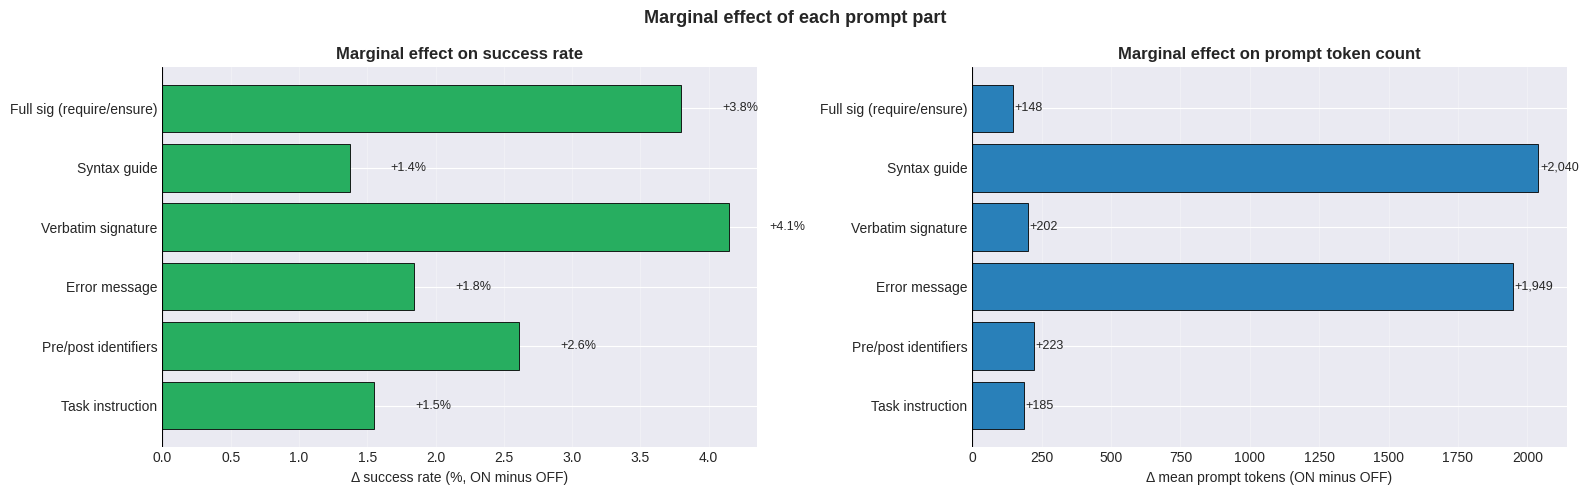

In [4]:
# ── marginal effect of each prompt part ──────────────────────────────────────
metrics = {
    'success':                    ('Success rate', lambda s: s.mean() * 100, '%'),
    'total_elapsed_time_seconds': ('Elapsed time', 'mean', 's'),
    'total_prompt_tokens':        ('Prompt tokens',     'mean', 'tok'),
    'total_completion_tokens':    ('Completion tokens', 'mean', 'tok'),
    'total_cost':                 ('Cost per run',      'mean', '$'),
}

rows = []
for p in PARTS:
    enabled  = df[df[f'has_{p}']]
    disabled = df[~df[f'has_{p}']]
    row = {'part': p, 'label': PART_LABELS[p],
           'n_enabled': len(enabled), 'n_disabled': len(disabled)}
    for col, (_, agg_fn, _) in metrics.items():
        fn = agg_fn if callable(agg_fn) else lambda s, f=agg_fn: getattr(s, f)()
        e_val = fn(enabled[col])  if len(enabled)  else np.nan
        d_val = fn(disabled[col]) if len(disabled) else np.nan
        row[f'{col}_on']    = e_val
        row[f'{col}_off']   = d_val
        row[f'{col}_delta'] = e_val - d_val
    rows.append(row)

mg = pd.DataFrame(rows)

print('Marginal effect: ON minus OFF  (positive = including the part helps)\n')
summary = mg[['part', 'label', 'n_enabled', 'n_disabled']].copy()
for col, (name, _, unit) in metrics.items():
    summary[f'Δ {name} ({unit})'] = mg[f'{col}_delta'].round(3)
with pd.option_context('display.width', 200):
    display(summary)

# ── figure: success-rate delta per part ──
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# left: success rate Δ
ax = axes[0]
deltas = mg['success_delta'].values
colors = ['#27ae60' if d >= 0 else '#e74c3c' for d in deltas]
bars = ax.barh(mg['label'], deltas, color=colors, edgecolor='black', linewidth=0.6)
for bar, val in zip(bars, deltas):
    x = val + (0.3 if val >= 0 else -0.3)
    ax.text(x, bar.get_y() + bar.get_height()/2,
            f'{val:+.1f}%', va='center', ha='left' if val >= 0 else 'right', fontsize=9)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Δ success rate (%, ON minus OFF)')
ax.set_title('Marginal effect on success rate', fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# right: token delta
ax = axes[1]
tok_deltas = mg['total_prompt_tokens_delta'].values
colors2 = ['#2980b9' if d >= 0 else '#bdc3c7' for d in tok_deltas]
bars2 = ax.barh(mg['label'], tok_deltas, color=colors2, edgecolor='black', linewidth=0.6)
for bar, val in zip(bars2, tok_deltas):
    x = val + (5 if val >= 0 else -5)
    ax.text(x, bar.get_y() + bar.get_height()/2,
            f'{val:+,.0f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Δ mean prompt tokens (ON minus OFF)')
ax.set_title('Marginal effect on prompt token count', fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

fig.suptitle('Marginal effect of each prompt part', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

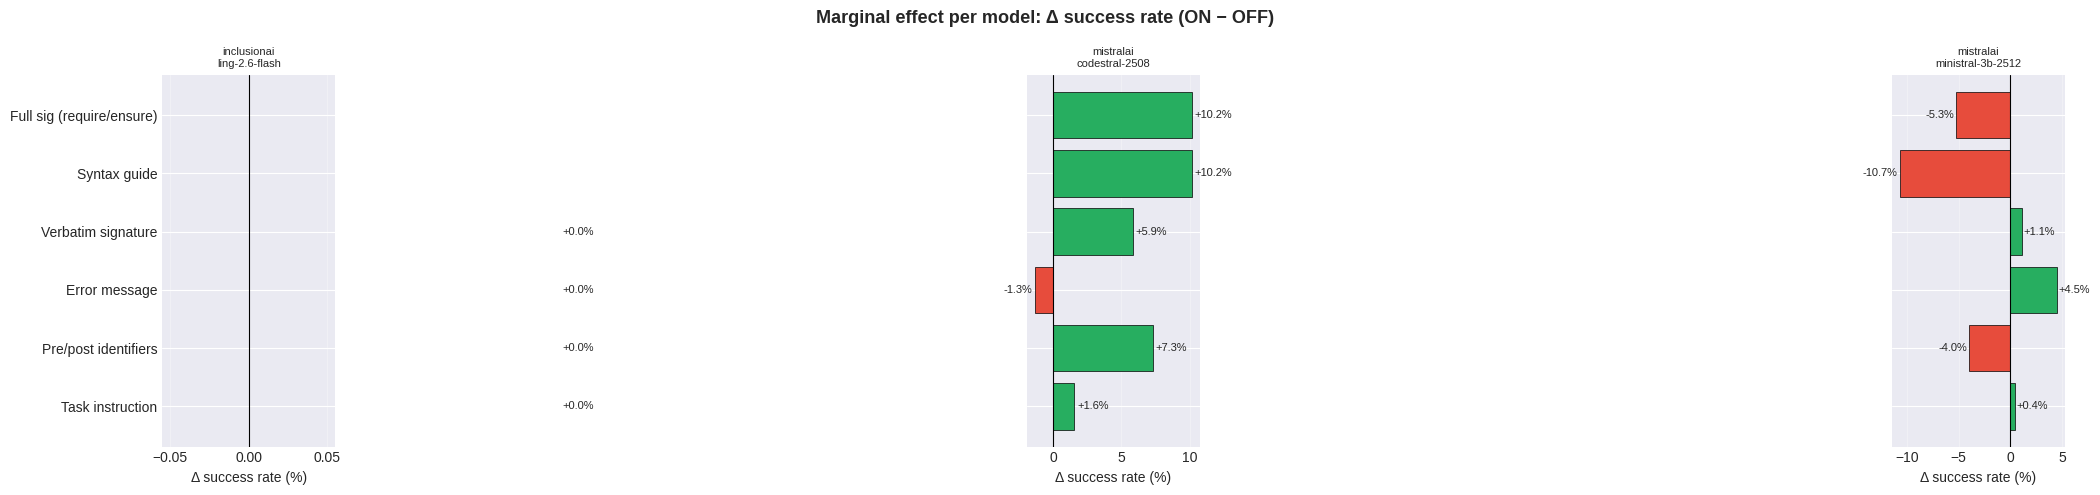

In [5]:
# ── marginal effect broken out per model ─────────────────────────────────────
mg_model_rows = []
for model in models:
    sub = df[df['model_slug'] == model]
    for p in PARTS:
        enabled  = sub[sub[f'has_{p}']]
        disabled = sub[~sub[f'has_{p}']]
        mg_model_rows.append({
            'model': model,
            'part':  p,
            'n_on':  len(enabled),
            'n_off': len(disabled),
            'succ_on':  enabled['success'].mean()  * 100 if len(enabled)  else np.nan,
            'succ_off': disabled['success'].mean() * 100 if len(disabled) else np.nan,
            'delta':    (enabled['success'].mean() - disabled['success'].mean()) * 100
                         if len(enabled) and len(disabled) else np.nan,
        })
mg_m = pd.DataFrame(mg_model_rows)

n_models = len(models)
fig, axes = plt.subplots(1, n_models, figsize=(7 * n_models, 5), sharey=True)
if n_models == 1:
    axes = [axes]

for ax, model in zip(axes, models):
    sub = mg_m[mg_m['model'] == model]
    labels = [PART_LABELS[p] for p in PARTS]
    deltas = sub.set_index('part').loc[PARTS, 'delta'].values
    colors = ['#27ae60' if (not np.isnan(d) and d >= 0) else '#e74c3c' for d in deltas]
    bars = ax.barh(labels, deltas, color=colors, edgecolor='black', linewidth=0.5)
    for bar, val in zip(bars, deltas):
        if not np.isnan(val):
            x = val + (0.2 if val >= 0 else -0.2)
            ax.text(x, bar.get_y() + bar.get_height()/2,
                    f'{val:+.1f}%', va='center',
                    ha='left' if val >= 0 else 'right', fontsize=8)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(model.replace('_', '\n'), fontsize=8)
    ax.set_xlabel('Δ success rate (%)')
    ax.grid(True, alpha=0.3, axis='x')

fig.suptitle('Marginal effect per model: Δ success rate (ON − OFF)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

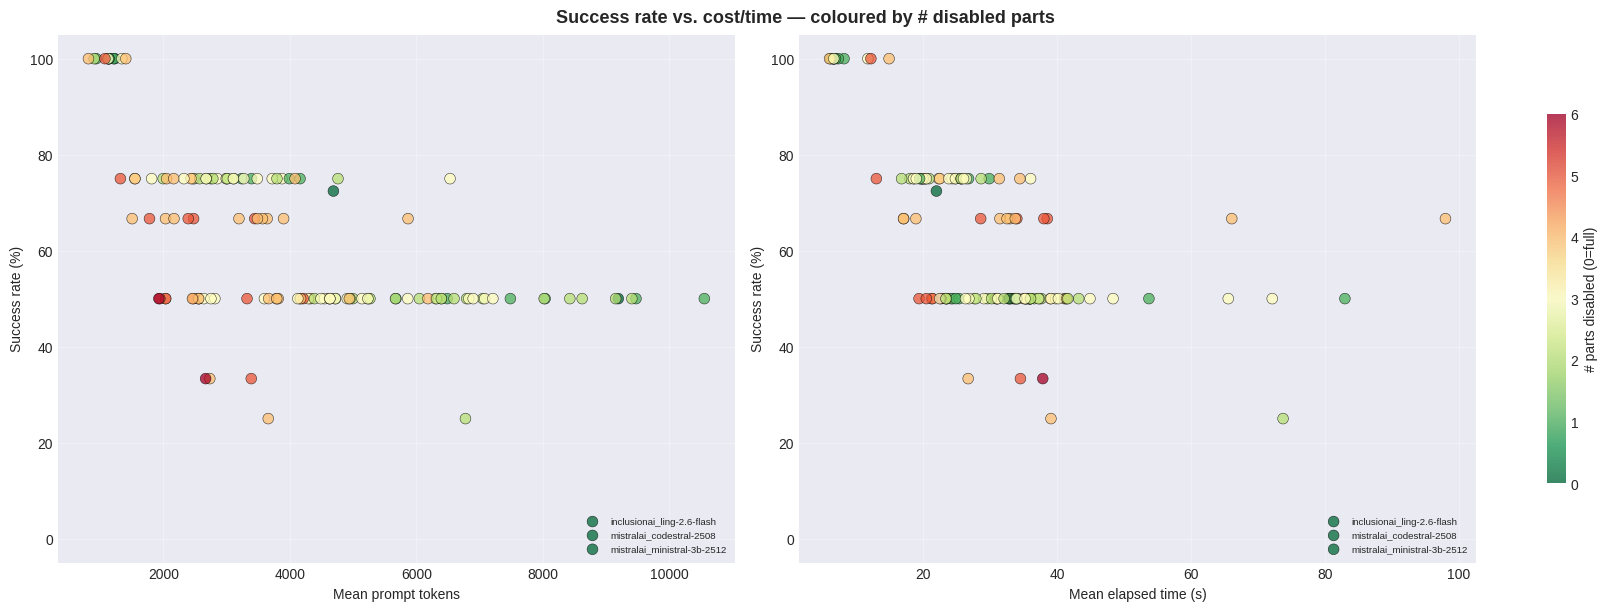

In [6]:
# ── cost / token efficiency: success rate vs prompt tokens ───────────────────
# Each dot = one (model, ablation) pair
eff = (
    df.groupby(['model_slug', 'ablation_tag'])
    .agg(
        success_rate       = ('success', 'mean'),
        mean_prompt_tokens = ('total_prompt_tokens', 'mean'),
        mean_cost          = ('total_cost', 'mean'),
        mean_elapsed       = ('total_elapsed_time_seconds', 'mean'),
        n                  = ('success', 'count'),
        n_parts_off        = ('n_parts_off', 'first'),
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

for ax, (xcol, xlabel) in zip(axes, [
    ('mean_prompt_tokens', 'Mean prompt tokens'),
    ('mean_elapsed',       'Mean elapsed time (s)'),
]):
    for model in models:
        sub = eff[eff['model_slug'] == model]
        sc = ax.scatter(
            sub[xcol], sub['success_rate'] * 100,
            c=sub['n_parts_off'], cmap='RdYlGn_r',
            vmin=0, vmax=len(PARTS),
            s=60, alpha=0.75, edgecolors='black', linewidth=0.4,
            label=model,
        )
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Success rate (%)')
    ax.set_ylim(-5, 105)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7, loc='lower right')

fig.colorbar(sc, ax=axes, label='# parts disabled (0=full)', shrink=0.7)
fig.suptitle('Success rate vs. cost/time — coloured by # disabled parts',
             fontsize=13, fontweight='bold')
plt.show()

/usr/lib/python3.14/site-packages/seaborn/utils.py:61: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Liberation Sans.
  fig.canvas.draw()
/usr/lib/python3.14/site-packages/seaborn/utils.py:61: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Liberation Sans.
  fig.canvas.draw()
/usr/lib/python3.14/site-packages/seaborn/utils.py:61: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Liberation Sans.
  fig.canvas.draw()
/usr/lib/python3.14/site-packages/seaborn/utils.py:61: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Liberation Sans.
  fig.canvas.draw()
/tmp/ipykernel_61104/1848858705.py:60: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_61104/1848858705.py:60: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}

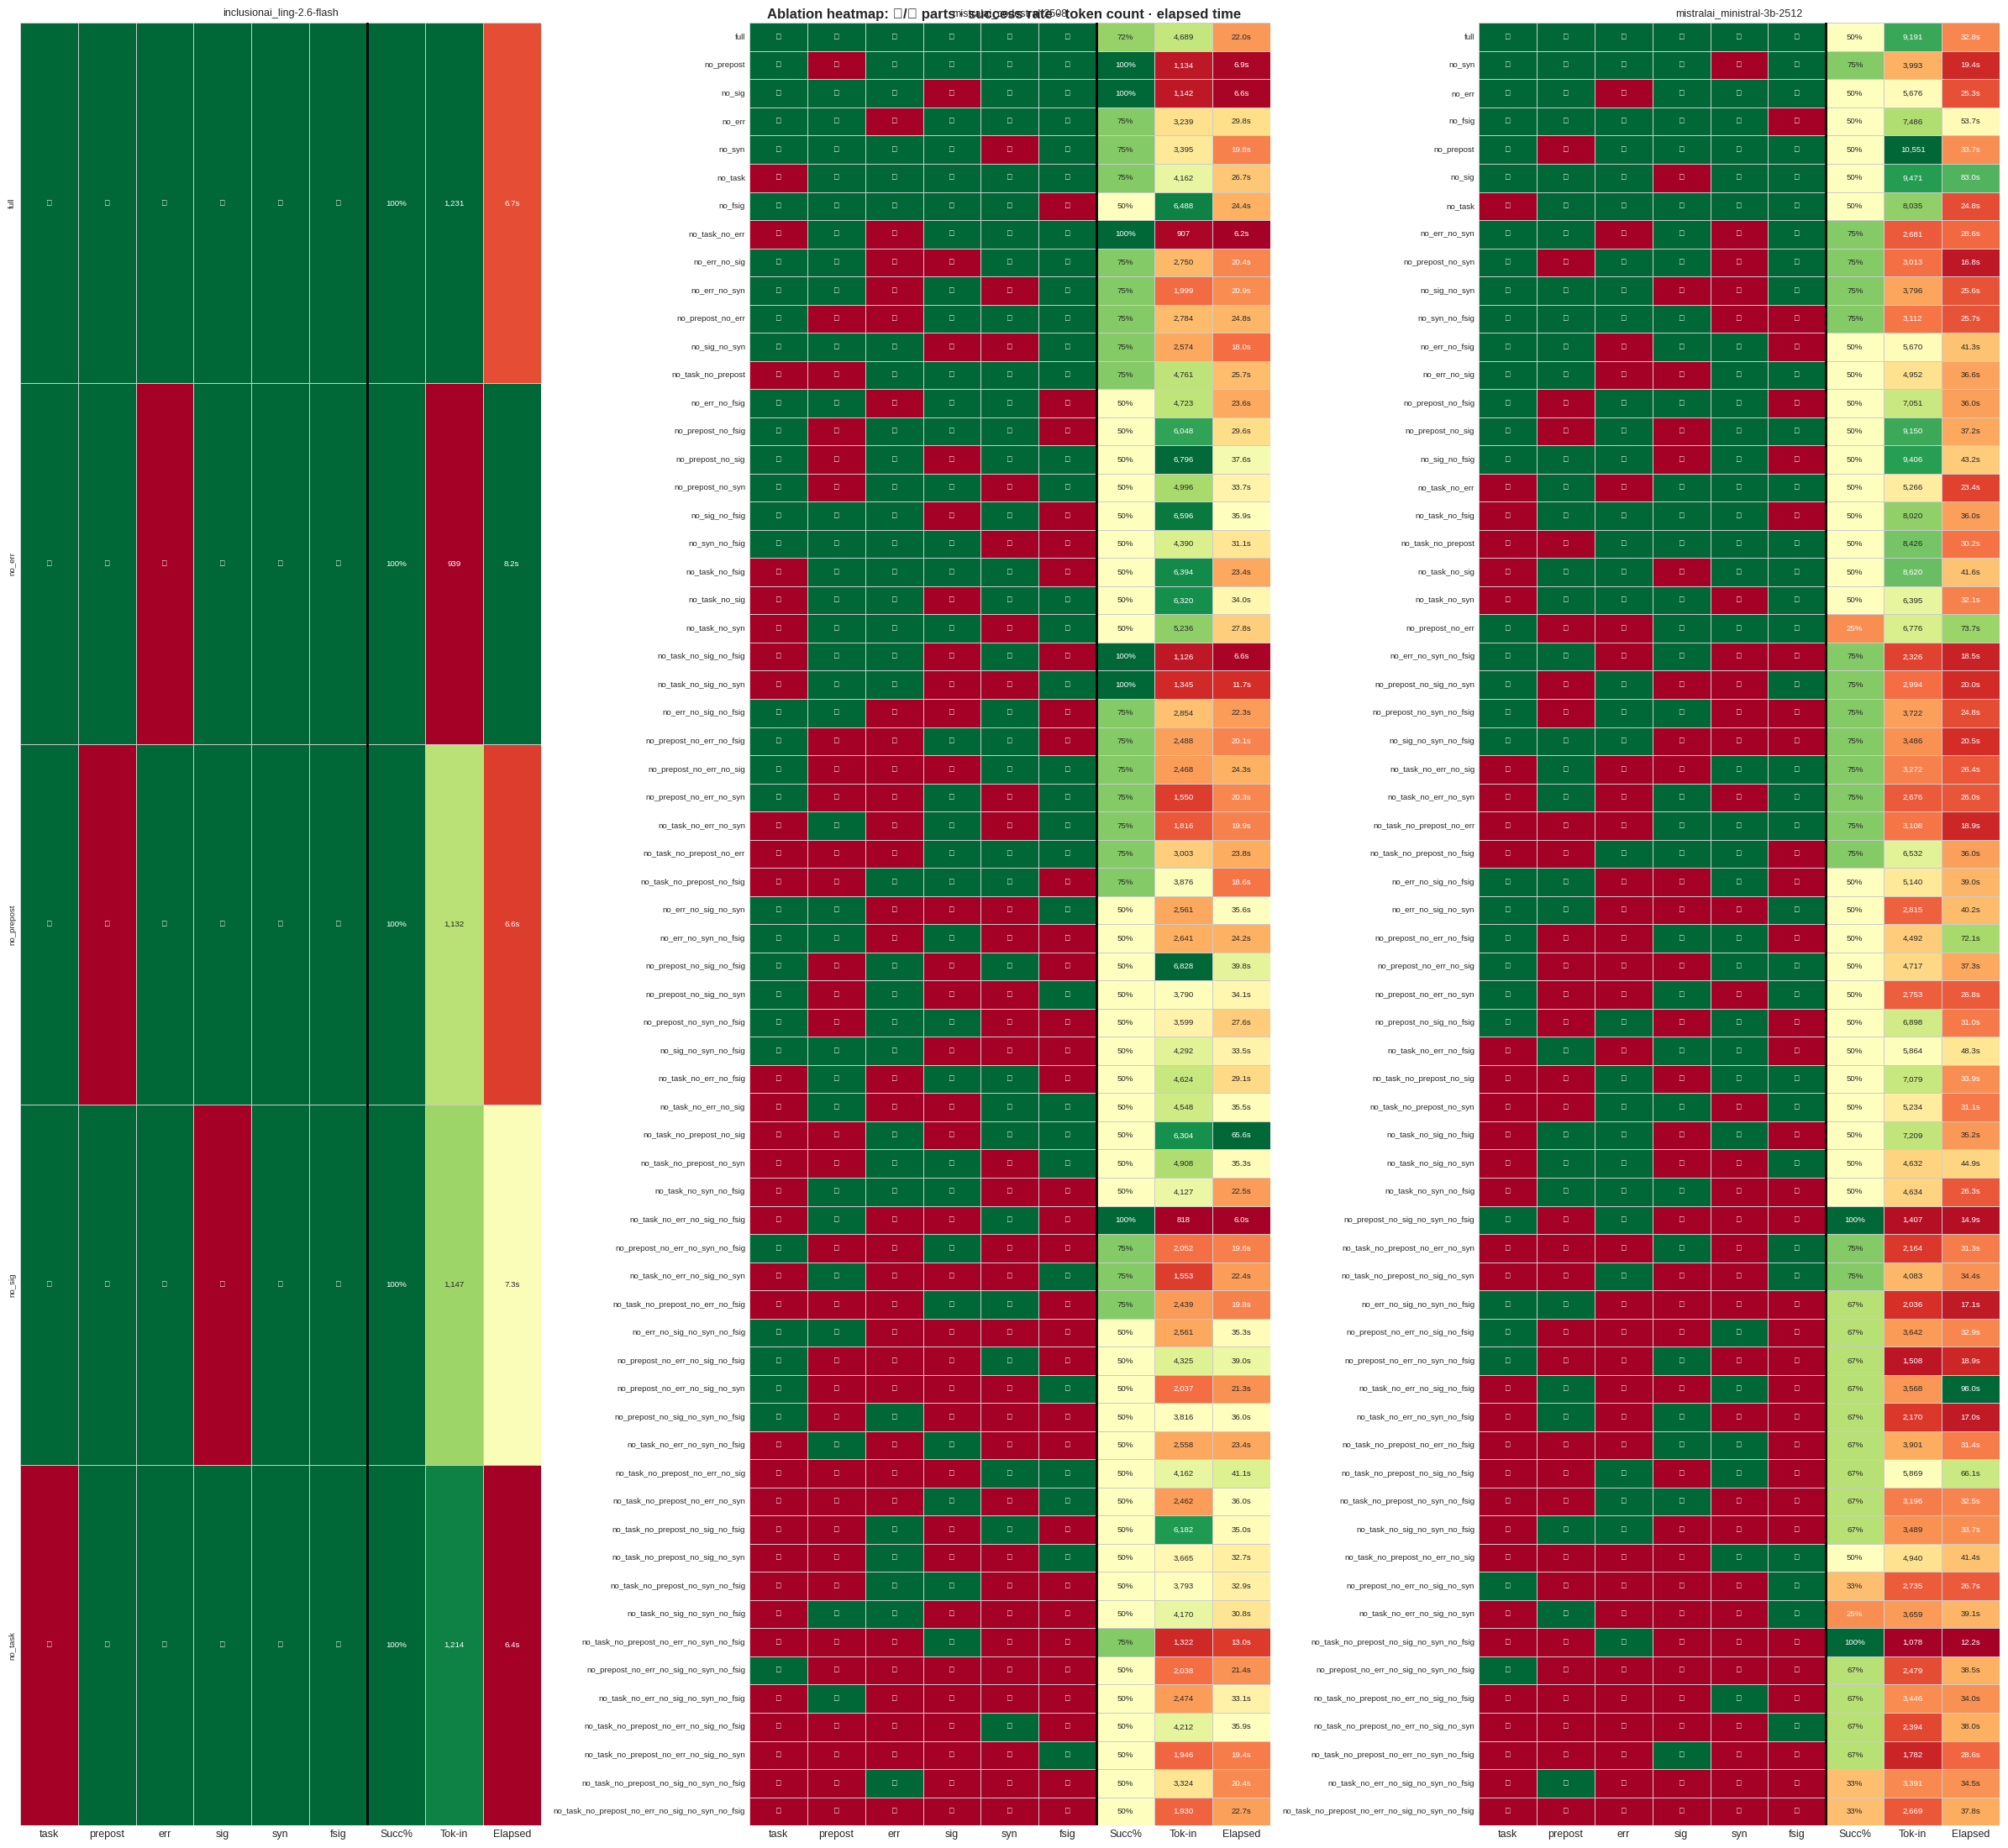

In [7]:
# ── heatmap: parts × metrics, averaged across all models ─────────────────────
# Rows = ablation tags (sorted by Hamming weight then success rate);
# Columns = part flags + success rate + mean prompt tokens (normalised)

fig, axes = plt.subplots(1, len(models), figsize=(8 * len(models), max(12, 0.35 * len(agg))))
if len(models) == 1:
    axes = [axes]

for ax, model in zip(axes, models):
    sub_df = df[df['model_slug'] == model]
    sub_agg = (
        sub_df.groupby('ablation_tag')
        .agg(
            success_rate       = ('success', 'mean'),
            mean_prompt_tokens = ('total_prompt_tokens', 'mean'),
            mean_elapsed       = ('total_elapsed_time_seconds', 'mean'),
            n_parts_off        = ('n_parts_off', 'first'),
        )
        .reset_index()
    )
    part_f = sub_df.groupby('ablation_tag')[[f'has_{p}' for p in PARTS]].first().reset_index()
    sub_agg = sub_agg.merge(part_f, on='ablation_tag')
    sub_agg = sub_agg.sort_values(['n_parts_off', 'success_rate'], ascending=[True, False])

    mat   = sub_agg[[f'has_{p}' for p in PARTS]].astype(float).values
    rates = sub_agg['success_rate'].values
    toks  = sub_agg['mean_prompt_tokens'].values
    elapsed = sub_agg['mean_elapsed'].values

    # Normalise tokens and elapsed to [0,1] for the heatmap colour scale
    tok_norm  = (toks  - toks.min())  / (toks.max()  - toks.min()  + 1e-9)
    el_norm   = (elapsed - elapsed.min()) / (elapsed.max() - elapsed.min() + 1e-9)

    combined = np.hstack([mat, rates.reshape(-1, 1),
                          tok_norm.reshape(-1, 1), el_norm.reshape(-1, 1)])

    annot = np.empty(combined.shape, dtype=object)
    for r in range(len(sub_agg)):
        for c in range(len(PARTS)):
            annot[r, c] = '✓' if mat[r, c] == 1 else '✗'
        annot[r, len(PARTS)]     = f'{rates[r]*100:.0f}%'
        annot[r, len(PARTS) + 1] = f'{toks[r]:,.0f}'
        annot[r, len(PARTS) + 2] = f'{elapsed[r]:.1f}s'

    col_labels = PARTS + ['Succ%', 'Tok-in', 'Elapsed']
    sns.heatmap(combined, ax=ax,
                xticklabels=col_labels,
                yticklabels=sub_agg['ablation_tag'].values,
                cmap='RdYlGn', vmin=0, vmax=1,
                linewidths=0.4, linecolor='#ccc',
                annot=annot, fmt='', annot_kws={'size': 7},
                cbar=False)
    ax.set_title(model, fontsize=9)
    ax.tick_params(axis='y', labelsize=7)
    ax.tick_params(axis='x', labelsize=9)
    ax.axvline(len(PARTS), color='black', linewidth=2)

fig.suptitle('Ablation heatmap: ✓/✗ parts · success rate · token count · elapsed time',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

/tmp/ipykernel_61104/1155594945.py:56: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


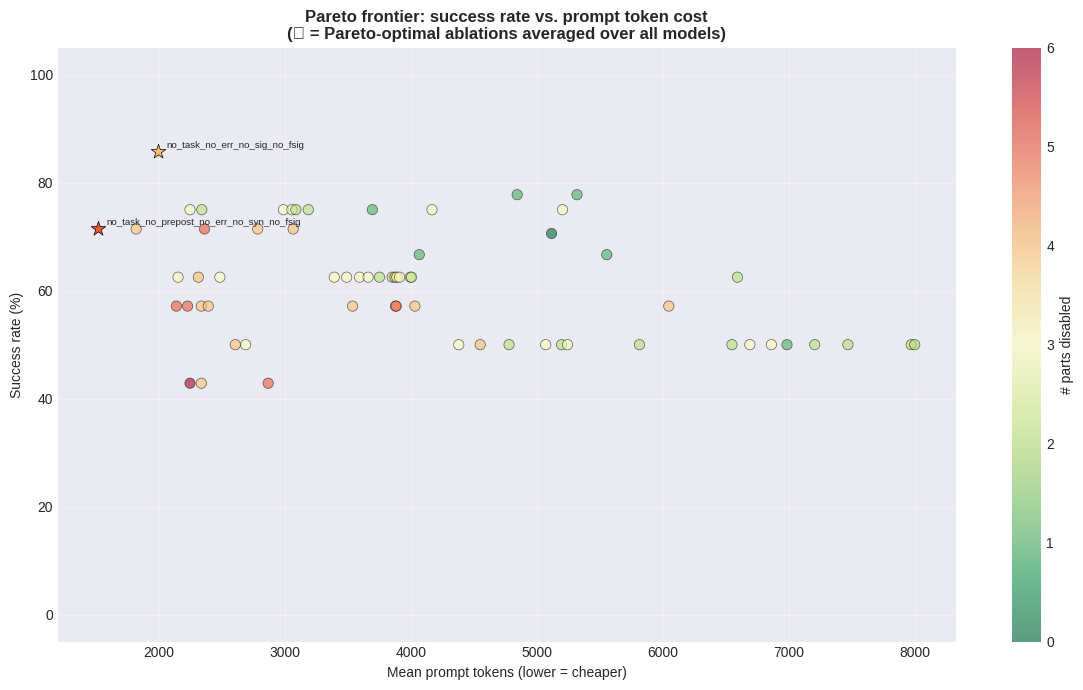

Pareto-optimal ablations (best success for given token budget):


'                            ablation_tag  n_parts_off    succ    tok-in   cost  elapsed(s)\nno_task_no_prepost_no_err_no_syn_no_fsig            5 71.4000 1519.5714 0.0003     19.6625\n           no_task_no_err_no_sig_no_fsig            4 85.7000 1996.2857 0.0002     45.4229'

In [8]:
# ── Pareto frontier: success rate vs mean prompt tokens (per ablation, avg over models) ──
pareto_df = (
    df.groupby('ablation_tag')
    .agg(
        success_rate       = ('success', 'mean'),
        mean_prompt_tokens = ('total_prompt_tokens', 'mean'),
        mean_cost          = ('total_cost', 'mean'),
        mean_elapsed       = ('total_elapsed_time_seconds', 'mean'),
        n_parts_off        = ('n_parts_off', 'first'),
    )
    .reset_index()
    .sort_values('mean_prompt_tokens')
)

# Simple Pareto (maximise success_rate, minimise mean_prompt_tokens)
pareto_front = []
best_succ = -1
for _, row in pareto_df.iterrows():
    if row['success_rate'] > best_succ:
        best_succ = row['success_rate']
        pareto_front.append(row['ablation_tag'])
pareto_df['pareto'] = pareto_df['ablation_tag'].isin(pareto_front)

fig, ax = plt.subplots(figsize=(12, 7))
scatter_kw = dict(edgecolors='black', linewidth=0.5)
sc = ax.scatter(
    pareto_df[~pareto_df['pareto']]['mean_prompt_tokens'],
    pareto_df[~pareto_df['pareto']]['success_rate'] * 100,
    c=pareto_df[~pareto_df['pareto']]['n_parts_off'],
    cmap='RdYlGn_r', vmin=0, vmax=len(PARTS),
    s=55, alpha=0.6, zorder=3, **scatter_kw
)
ax.scatter(
    pareto_df[pareto_df['pareto']]['mean_prompt_tokens'],
    pareto_df[pareto_df['pareto']]['success_rate'] * 100,
    c=pareto_df[pareto_df['pareto']]['n_parts_off'],
    cmap='RdYlGn_r', vmin=0, vmax=len(PARTS),
    s=120, marker='*', zorder=4, **scatter_kw
)

# Label selected points
for _, row in pareto_df[pareto_df['pareto']].iterrows():
    ax.annotate(row['ablation_tag'],
                xy=(row['mean_prompt_tokens'], row['success_rate'] * 100),
                xytext=(6, 3), textcoords='offset points', fontsize=7,
                arrowprops=dict(arrowstyle='-', color='grey', lw=0.5))

plt.colorbar(sc, ax=ax, label='# parts disabled')
ax.set_xlabel('Mean prompt tokens (lower = cheaper)')
ax.set_ylabel('Success rate (%)')
ax.set_ylim(-5, 105)
ax.set_title('Pareto frontier: success rate vs. prompt token cost\n'
             '(★ = Pareto-optimal ablations averaged over all models)',
             fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('Pareto-optimal ablations (best success for given token budget):')
display(pareto_df[pareto_df['pareto']][['ablation_tag', 'n_parts_off', 'success_rate',
                                         'mean_prompt_tokens', 'mean_cost', 'mean_elapsed']]
        .rename(columns={'success_rate': 'succ', 'mean_prompt_tokens': 'tok-in',
                         'mean_cost': 'cost', 'mean_elapsed': 'elapsed(s)'})
        .assign(succ=lambda d: (d['succ']*100).round(1))
        .to_string(index=False, float_format='{:.4f}'.format))

Timing per model:


,model_slug,n,succ_rate,med_elapsed,mean_elapsed,med_verif,med_ai,total_h
0,inclusionai_ling-2.6-flash,5,1.00,6.66,7.03,2.10,2.41,0.01
1,mistralai_codestral-2508,281,0.63,6.45,25.81,2.28,1.56,2.01
2,mistralai_ministral-3b-2512,238,0.59,14.44,34.69,6.75,3.79,2.29


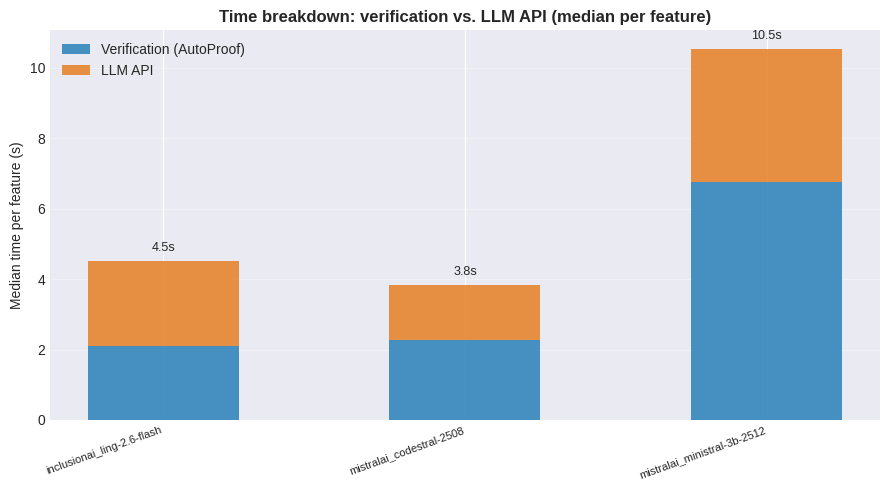

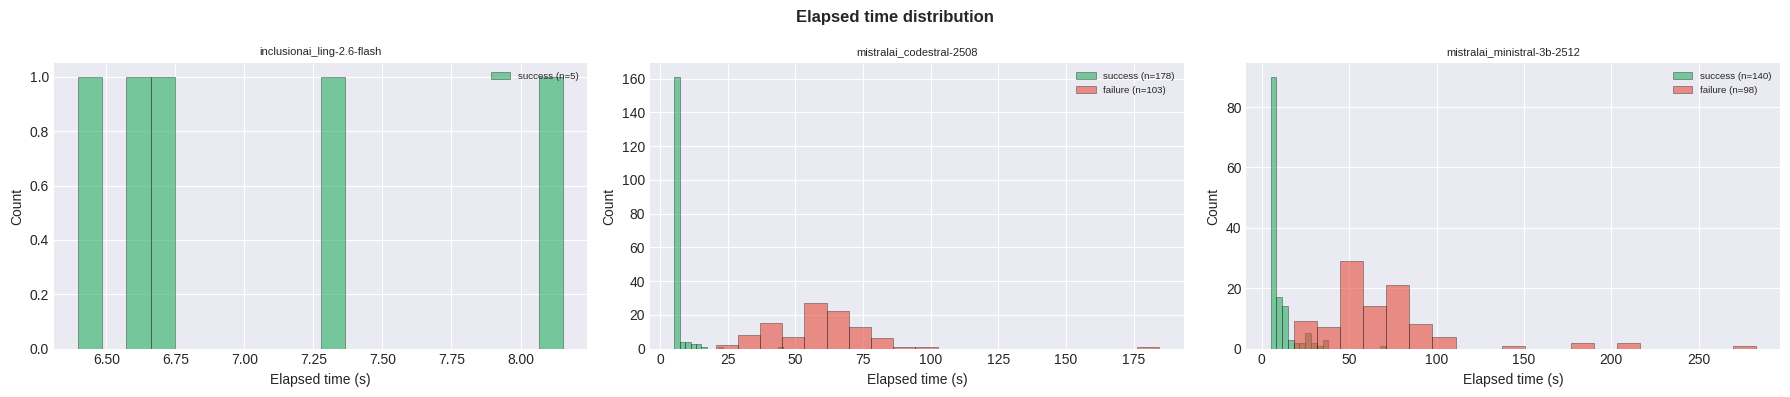

In [9]:
# ── timing breakdown ──────────────────────────────────────────────────────────
timing = (
    df.groupby('model_slug')
    .agg(
        n              = ('success', 'count'),
        succ_rate      = ('success', 'mean'),
        med_elapsed    = ('total_elapsed_time_seconds', 'median'),
        mean_elapsed   = ('total_elapsed_time_seconds', 'mean'),
        med_verif      = ('total_verification_time', 'median'),
        med_ai         = ('total_ai_time', 'median'),
        total_h        = ('total_elapsed_time_seconds', lambda s: s.sum() / 3600),
    )
    .reindex(models)
    .reset_index()
)
print('Timing per model:')
display(timing.round(2))

# Stacked bar: verif vs AI time
fig, ax = plt.subplots(figsize=(max(8, 3 * len(models)), 5))
x = np.arange(len(models))
w = 0.5
vv = timing['med_verif'].fillna(0).values
av = timing['med_ai'].fillna(0).values
ax.bar(x, vv, w, label='Verification (AutoProof)', color='#2980b9', alpha=0.85)
ax.bar(x, av, w, bottom=vv, label='LLM API', color='#e67e22', alpha=0.85)
for i, (v, a) in enumerate(zip(vv, av)):
    ax.text(i, v + a + 0.2, f'{v+a:.1f}s', ha='center', va='bottom', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=20, ha='right', fontsize=8)
ax.set_ylabel('Median time per feature (s)')
ax.set_title('Time breakdown: verification vs. LLM API (median per feature)',
             fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Elapsed distribution per model
fig, axes = plt.subplots(1, len(models), figsize=(6 * len(models), 4), sharey=False)
if len(models) == 1:
    axes = [axes]
for ax, model in zip(axes, models):
    sub = df[df['model_slug'] == model]
    for succ, label, color in [(True, 'success', '#27ae60'), (False, 'failure', '#e74c3c')]:
        vals = sub[sub['success'] == succ]['total_elapsed_time_seconds'].dropna()
        if len(vals):
            ax.hist(vals, bins=20, alpha=0.6, label=f'{label} (n={len(vals)})',
                    color=color, edgecolor='black', linewidth=0.4)
    ax.set_xlabel('Elapsed time (s)')
    ax.set_ylabel('Count')
    ax.set_title(model, fontsize=8)
    ax.legend(fontsize=7)
fig.suptitle('Elapsed time distribution', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

Cost & token summary per (model, ablation) — top 20 by mean cost:


,model_slug,ablation_tag,n,success_rate,mean_cost,mean_prompt_tokens,mean_compl_tokens
25,mistralai_codestral-2508,no_prepost_no_sig,4,0.5000,0.0021,6795.7500,778.500
57,mistralai_codestral-2508,no_task_no_prepost_no_sig,4,0.5000,0.0019,6304.2500,758.750
26,mistralai_codestral-2508,no_prepost_no_sig_no_fsig,4,0.5000,0.0018,6828.0000,760.500
14,mistralai_codestral-2508,no_fsig,4,0.5000,0.0017,6487.5000,587.750
63,mistralai_codestral-2508,no_task_no_sig,4,0.5000,0.0017,6319.5000,614.750
46,mistralai_codestral-2508,no_task_no_fsig,4,0.5000,0.0017,6394.0000,615.250
24,mistralai_codestral-2508,no_prepost_no_fsig,4,0.5000,0.0016,6048.0000,662.000
32,mistralai_codestral-2508,no_sig_no_fsig,4,0.5000,0.0016,6595.7500,695.250
67,mistralai_codestral-2508,no_task_no_syn,4,0.5000,0.0016,5235.5000,761.250
29,mistralai_codestral-2508,no_prepost_no_syn,4,0.5000,0.0016,4996.0000,729.250


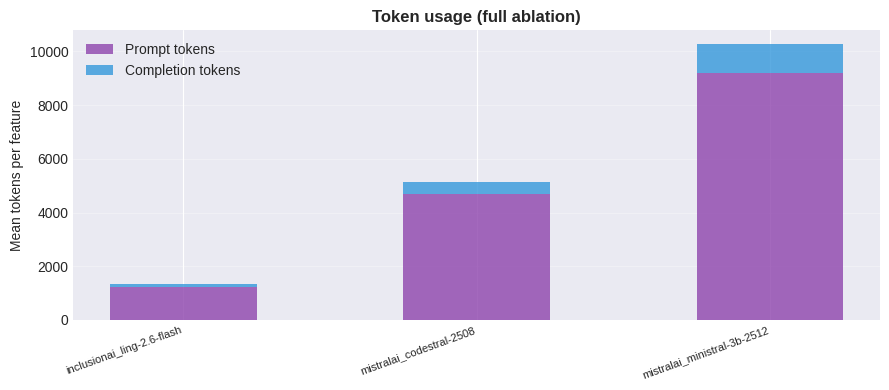

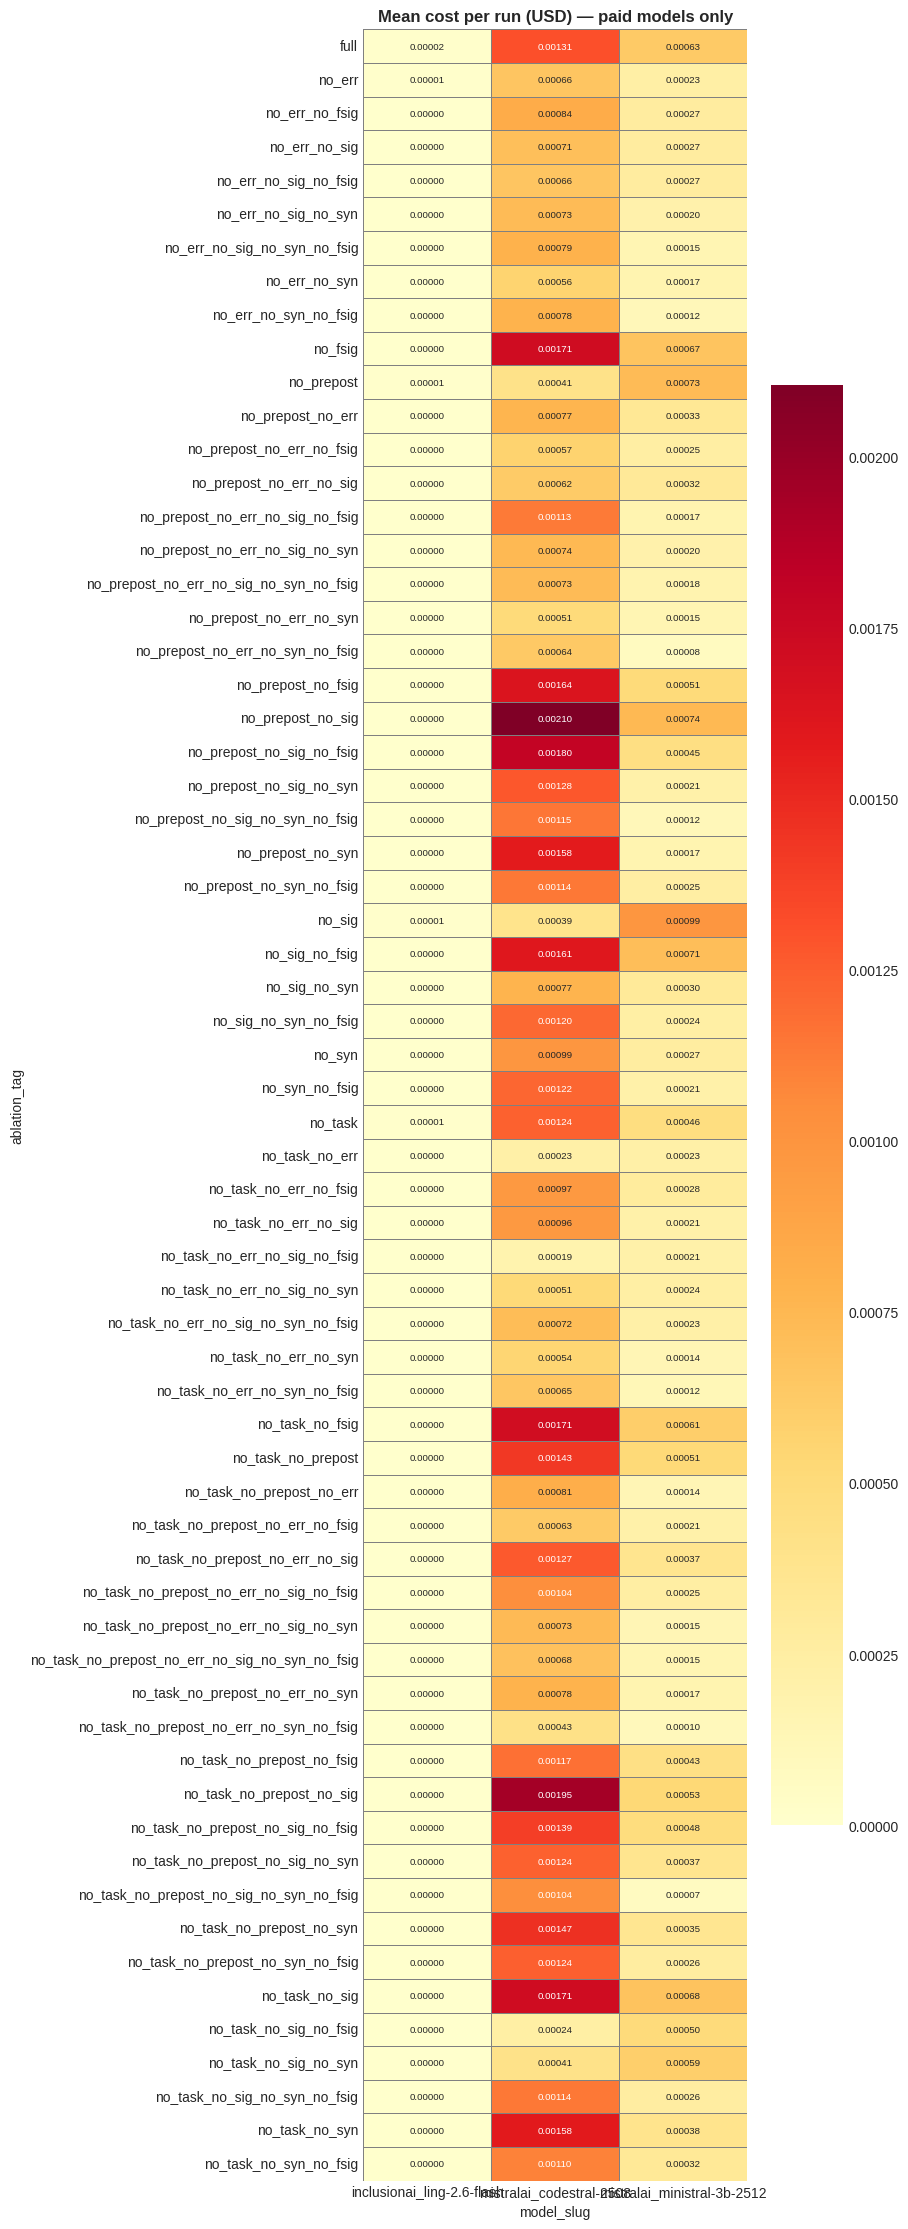

In [10]:
# ── cost & token analysis ─────────────────────────────────────────────────────
cost_by_abl = (
    df.groupby(['model_slug', 'ablation_tag'])
    .agg(
        n                  = ('success', 'count'),
        success_rate       = ('success', 'mean'),
        total_cost         = ('total_cost', 'sum'),
        mean_cost          = ('total_cost', 'mean'),
        mean_prompt_tokens = ('total_prompt_tokens', 'mean'),
        mean_compl_tokens  = ('total_completion_tokens', 'mean'),
    )
    .reset_index()
)

print('Cost & token summary per (model, ablation) — top 20 by mean cost:')
display(cost_by_abl.sort_values('mean_cost', ascending=False).head(20)
        [['model_slug', 'ablation_tag', 'n', 'success_rate',
          'mean_cost', 'mean_prompt_tokens', 'mean_compl_tokens']]
        .round(4))

# Token breakdown for full ablation
full_rows = df[df['ablation_tag'] == 'full']
if not full_rows.empty:
    tok = (
        full_rows.groupby('model_slug')
        .agg(mean_prompt=('total_prompt_tokens', 'mean'),
             mean_compl =('total_completion_tokens', 'mean'))
        .reindex(models)
    )
    fig, ax = plt.subplots(figsize=(max(8, 3 * len(models)), 4))
    x = np.arange(len(models))
    w = 0.5
    ax.bar(x, tok['mean_prompt'].values, w, label='Prompt tokens', color='#8e44ad', alpha=0.8)
    ax.bar(x, tok['mean_compl'].values, w,
           bottom=tok['mean_prompt'].values, label='Completion tokens', color='#3498db', alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=20, ha='right', fontsize=8)
    ax.set_ylabel('Mean tokens per feature')
    ax.set_title('Token usage (full ablation)', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

# Cost heatmap — paid models only
paid = cost_by_abl[cost_by_abl['total_cost'] > 0]
if not paid.empty:
    pivot = paid.pivot(index='ablation_tag', columns='model_slug',
                       values='mean_cost').fillna(0)
    fig, ax = plt.subplots(figsize=(max(6, 3 * len(pivot.columns)), max(4, 0.35 * len(pivot))))
    sns.heatmap(pivot, ax=ax, cmap='YlOrRd', fmt='.5f', annot=True,
                linewidths=0.4, linecolor='grey', annot_kws={'size': 7})
    ax.set_title('Mean cost per run (USD) — paid models only',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('All models are free-tier. No cost heatmap.')

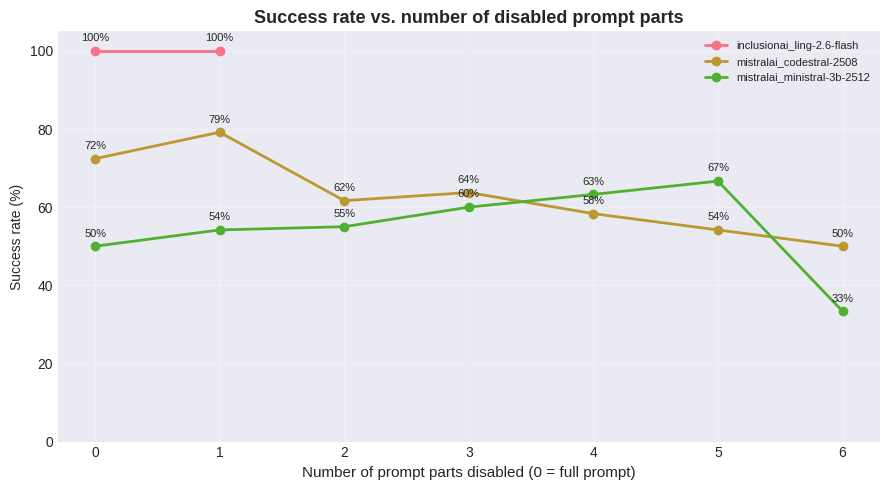

In [11]:
# ── success rate vs number of disabled parts ──────────────────────────────────
by_noff = (
    df.groupby(['model_slug', 'n_parts_off'])
    .agg(success_rate=('success', 'mean'), n=('success', 'count'))
    .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 5))
for model in models:
    sub = by_noff[by_noff['model_slug'] == model].sort_values('n_parts_off')
    ax.plot(sub['n_parts_off'], sub['success_rate'] * 100,
            marker='o', linewidth=2, label=model)
    for _, row in sub.iterrows():
        ax.annotate(f"{row['success_rate']*100:.0f}%",
                    xy=(row['n_parts_off'], row['success_rate'] * 100),
                    xytext=(0, 7), textcoords='offset points',
                    ha='center', fontsize=8)

ax.set_xlabel('Number of prompt parts disabled (0 = full prompt)', fontsize=11)
ax.set_ylabel('Success rate (%)')
ax.set_xticks(range(len(PARTS) + 1))
ax.set_ylim(0, 105)
ax.set_title('Success rate vs. number of disabled prompt parts',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()